In [3]:
%reset -f

import os
import easygui
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import pandas as pd



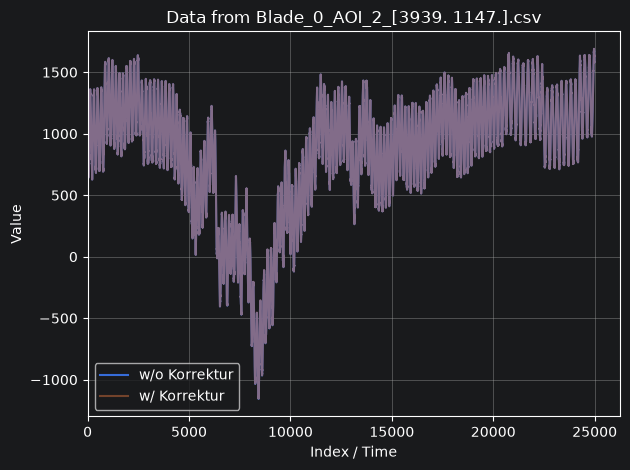

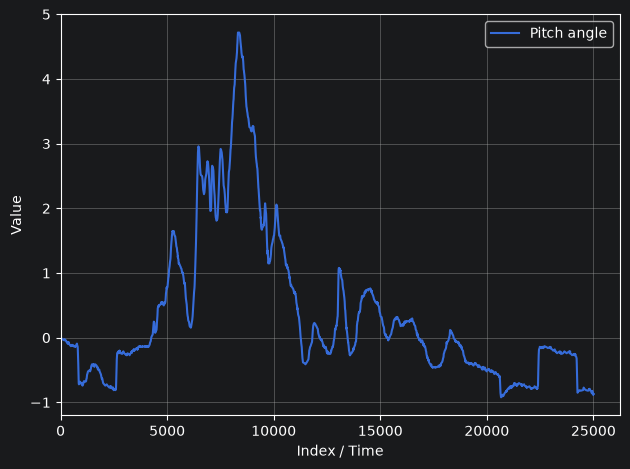

In [4]:
v_i = 0000
v_f = 25000

# Open file dialog to select a .mat file
mat_file_path = easygui.fileopenbox("Select the .mat file")

mat_data = scipy.io.loadmat(mat_file_path)


file_path = easygui.fileopenbox("Select the .csv file")
df = pd.read_csv(file_path, sep=";", decimal=',', skiprows=1, header=0)

mat_data = mat_data["pitch_wea_bladeA"].flatten()
mat_data = mat_data[v_i:v_f] - mat_data[0]

y_pos = df["Y [mm]"].to_numpy(copy=True)[v_i:v_f]
sigma = df["sigma [pixel]"].to_numpy(copy=True)[v_i:v_f]
deformation_V = df["V [mm]"].to_numpy(copy=True)[v_i:v_f]


real_V = deformation_V - y_pos * np.sin(np.radians(mat_data))**2
aaa = y_pos * np.sin(np.radians(mat_data))**2

fig, ax = plt.subplots()
ax.plot(deformation_V)
ax.plot(real_V, alpha=0.5)

filename = os.path.basename(file_path)
ax.set_title(f"Data from {filename}")
ax.set_xlabel("Index / Time")
ax.set_ylabel("Value")
ax.grid(True)
ax.set_xlim(0)
ax.legend(["w/o Korrektur", "w/ Korrektur"])
plt.tight_layout()
plt.show()

# Create a plot for the variables found
fig1, ax1 = plt.subplots()

ax1.plot(mat_data)

filename = os.path.basename(file_path)
ax1.set_xlabel("Index / Time")
ax1.set_ylabel("Value")
ax1.grid(True)
ax1.legend(["Pitch angle"])
ax1.set_xlim(0)
plt.tight_layout()
plt.show()

In [11]:
positive_angle = np.nonzero((mat_data < 0) & (mat_data < 1))[0]


new = mat_data[positive_angle]